In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import SobolevTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets


In [2]:
n_assets = 3

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5, 0.6])
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 8.0
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=3, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = n_assets + 1
hidden_sizes = [64, 64, 64]
output_size = 1
activation = nn.Mish()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_product = PutProductMultipleAssets()
trainer_product = SobolevTrainer(model_config, market_params, put_product, 67)
trainer_product.train(batch_size=1000, epochs=5000, tol=1e-3)

/Users/jameswu/Documents/Imperial/Year 4/M4R/neural_network/trainer.py:140: RuntimeWarning: divide by zero encountered in divide
  sobolev_loss = self.payoff.sobolev_loss(self.model, t1_interior, t2_interior, S_interior, S1_boundary, S2_boundary, a=1/S_min, b=S_max, K=K, face1=face1, face2=face2)


Iteration 0, Loss: 161.67344665527344
Iteration 100, Loss: 66.45575714111328
Iteration 200, Loss: 34.98386764526367
Iteration 300, Loss: 12.008790969848633
Iteration 400, Loss: 22.348655700683594
Iteration 500, Loss: 8.711661338806152
Iteration 600, Loss: 7.680335998535156
Converged at epoch 689


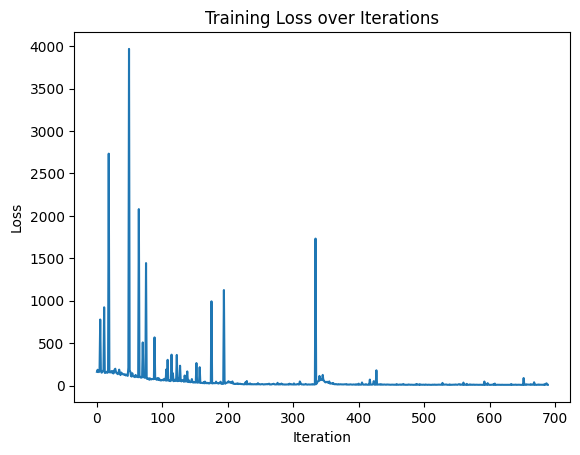

In [6]:
trainer_product.plot_losses()